In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
orders=pd.read_csv("Orders.csv")
customers=pd.read_csv("Customers.csv")
products=pd.read_csv("Products.csv")
returns=pd.read_csv("Returns.csv")

In [3]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales,Profit
0,O0001,2024-02-22,C088,P008,2,18788,3879.37
1,O0002,2024-05-30,C056,P013,5,44365,10406.60
2,O0003,2024-04-16,C071,P009,4,219748,29327.16
3,O0004,2024-05-31,C084,P011,1,55695,4713.73
4,O0005,2024-06-09,C093,P020,3,34026,5324.17


In [4]:
orders.tail()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales,Profit
995,O0996,2024-07-08,C046,P010,3,18660,3787.35
996,O0997,2024-07-07,C040,P014,4,216748,34875.48
997,O0998,2024-03-08,C042,P020,4,45368,4797.97
998,O0999,2024-12-21,C090,P016,3,163152,30719.81
999,O1000,2024-01-25,C033,P014,5,270935,43393.36


In [5]:
orders.sample(5)

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales,Profit
853,O0854,2024-05-06,C015,P006,5,33735,5292.08
24,O0025,2024-10-04,C088,P015,4,44940,7791.51
833,O0834,2024-08-31,C055,P012,4,24100,3361.20
564,O0565,2024-12-02,C069,P011,3,167085,30063.21
728,O0729,2024-08-07,C086,P020,2,22684,5100.64


In [6]:
orders.shape

(1000, 7)

In [7]:
orders.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Quantity',
       'Sales', 'Profit'],
      dtype='object')

In [8]:
orders.dtypes

Order_ID        object
Order_Date      object
Customer_ID     object
Product_ID      object
Quantity         int64
Sales            int64
Profit         float64
dtype: object

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     1000 non-null   object 
 1   Order_Date   1000 non-null   object 
 2   Customer_ID  1000 non-null   object 
 3   Product_ID   1000 non-null   object 
 4   Quantity     1000 non-null   int64  
 5   Sales        1000 non-null   int64  
 6   Profit       1000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


In [10]:
orders.describe()

,Quantity,Sales,Profit
count,1000.000000,1000.00000,1000.000000
mean,3.011000,68871.27500,11366.565600
std,1.390976,73303.42538,13025.180952
min,1.000000,6025.00000,580.510000
25%,2.000000,20241.00000,3004.942500
50%,3.000000,35775.00000,5933.215000
75%,4.000000,96944.00000,13745.502500
max,5.000000,279750.00000,66476.960000


In [11]:
orders.isnull().sum()

Order_ID       0
Order_Date     0
Customer_ID    0
Product_ID     0
Quantity       0
Sales          0
Profit         0
dtype: int64

In [12]:
orders.dropna(inplace=True)

In [13]:
# orders["Profit"].fillna(0,inplace=True)

In [14]:
orders.duplicated().sum()

np.int64(0)

In [15]:
orders.drop_duplicates(inplace=True)

In [16]:
orders["Order_Date"]=pd.to_datetime(orders["Order_Date"])

In [17]:
orders["Month"]=orders["Order_Date"].dt.month_name()

In [18]:
orders["Month"]

0      February
1           May
2         April
3           May
4          June
         ...   
995        July
996        July
997       March
998    December
999     January
Name: Month, Length: 1000, dtype: object

In [19]:
orders["Year"]=orders["Order_Date"].dt.year

In [20]:
orders["Year"]

0      2024
1      2024
2      2024
3      2024
4      2024
       ... 
995    2024
996    2024
997    2024
998    2024
999    2024
Name: Year, Length: 1000, dtype: int32

In [21]:
orders["Day"]=orders["Order_Date"].dt.day_name()

In [22]:
orders["Day"]

0      Thursday
1      Thursday
2       Tuesday
3        Friday
4        Sunday
         ...   
995      Monday
996      Sunday
997      Friday
998    Saturday
999    Thursday
Name: Day, Length: 1000, dtype: object

In [23]:
orders["Profit_Margin"]=(orders["Profit"]/orders["Sales"])*100

In [24]:
orders["Profit_Margin"]

0      20.648126
1      23.456779
2      13.345814
3       8.463471
4      15.647358
         ...    
995    20.296624
996    16.090335
997    10.575670
998    18.828951
999    16.016151
Name: Profit_Margin, Length: 1000, dtype: float64

In [25]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Sales,Profit,Month,Year,Day,Profit_Margin
0,O0001,2024-02-22,C088,P008,2,18788,3879.37,February,2024,Thursday,20.648126
1,O0002,2024-05-30,C056,P013,5,44365,10406.60,May,2024,Thursday,23.456779
2,O0003,2024-04-16,C071,P009,4,219748,29327.16,April,2024,Tuesday,13.345814
3,O0004,2024-05-31,C084,P011,1,55695,4713.73,May,2024,Friday,8.463471
4,O0005,2024-06-09,C093,P020,3,34026,5324.17,June,2024,Sunday,15.647358


In [26]:
orders.to_csv("Orders_Cleaned.csv",index=False)

In [27]:
orders["Sales"].sum()

np.int64(68871275)

In [28]:
total_sales=orders["Sales"].sum()
print("Total Sales:",total_sales)

Total Sales: 68871275


In [29]:
print("Total Sales:",orders["Sales"].sum())

Total Sales: 68871275


In [30]:
total_profit=orders["Profit"].sum()
print("Total Profit:",total_profit)

Total Profit: 11366565.6


In [31]:
orders["Order_ID"].count()

np.int64(1000)

In [32]:
len(orders)

1000

In [33]:
orders["Sales"].mean()  

np.float64(68871.275)

In [34]:
orders["Sales"].max()  

279750

In [35]:
orders["Sales"].min()  

6025

In [36]:
orders["Quantity"].sum()

np.int64(3011)

In [37]:
monthly_sales=orders.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
April        4211063
August       4929801
December     5955553
February     5806774
January      5612793
July         6274616
June         4224834
March        7018340
May          6228639
November     6067924
October      6761972
September    5778966
Name: Sales, dtype: int64


In [38]:
monthly_profit=orders.groupby("Month")["Profit"].sum()
print(monthly_profit)

Month
April         707760.06
August        846930.81
December      962360.75
February     1007139.00
January       896163.16
July          997191.67
June          696198.28
March        1122442.45
May          1061846.95
November     1028974.30
October      1080079.85
September     959478.32
Name: Profit, dtype: float64


In [39]:
top_customers=orders.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer_ID
C042    1894162
C100    1833988
C088    1627319
C056    1365388
C065    1269548
C039    1255453
C035    1209146
C020    1195592
C066    1175555
C037    1150195
Name: Sales, dtype: int64


In [40]:
orders_products=orders.merge(products,on="Product_ID")

In [41]:
top_products=orders_products.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product_Name
Laptop 16     8755824
Laptop 14     8669920
Laptop 11     8521335
Laptop 5      7944900
Laptop 9      7086873
Mobile 4      4327348
Mobile 19     4095884
Mobile 17     4020456
Printer 2     2019236
Printer 20    1792036
Name: Sales, dtype: int64


In [42]:
category_sales=orders_products.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture      9974683
Technology    58896592
Name: Sales, dtype: int64


In [43]:
orders_customers=orders.merge(customers,on="Customer_ID")

In [44]:
state_sales=orders_customers.groupby("State")["Sales"].sum().sort_values(ascending=False)
print(state_sales)

State
Maharashtra    29736460
Telangana      19906671
Delhi          11288335
Karnataka       7939809
Name: Sales, dtype: int64


In [45]:
products.head()

,Product_ID,Product_Name,Category,Sub_Category,Unit_Price
0,P001,Table 1,Furniture,Tables,9101
1,P002,Printer 2,Technology,Accessories,11156
2,P003,Table 3,Furniture,Tables,8626
3,P004,Mobile 4,Technology,Phones,25159
4,P005,Laptop 5,Technology,Computers,55950


In [46]:
city_sales=orders_customers.groupby("City")["Sales"].sum().sort_values(ascending=False)
print(city_sales)

City
Hyderabad    19906671
Mumbai       15174485
Pune         14561975
Delhi        11288335
Bengaluru     7939809
Name: Sales, dtype: int64


In [47]:
segment_sales=orders_customers.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
print(segment_sales)

Segment
Corporate      26467789
Home Office    24170969
Consumer       18232517
Name: Sales, dtype: int64


In [48]:
avg_profit=orders_products.groupby("Category")["Profit"].mean().sort_values(ascending=False)
print(avg_profit)

Category
Technology    17349.977665
Furniture      3720.337426
Name: Profit, dtype: float64


In [49]:
profit_products=orders_products.groupby("Product_Name")["Profit"].sum().sort_values(ascending=False).head(5)
print(profit_products)

Product_Name
Laptop 11    1542308.96
Laptop 16    1451215.08
Laptop 14    1408830.94
Laptop 5     1399280.10
Laptop 9     1007027.07
Name: Profit, dtype: float64


In [50]:
orders[["Sales","Profit","Quantity"]].corr()

,Sales,Profit,Quantity
Sales,1.000000,0.923328,0.470433
Profit,0.923328,1.000000,0.424140
Quantity,0.470433,0.424140,1.000000


In [52]:
import matplotlib.pyplot as plt

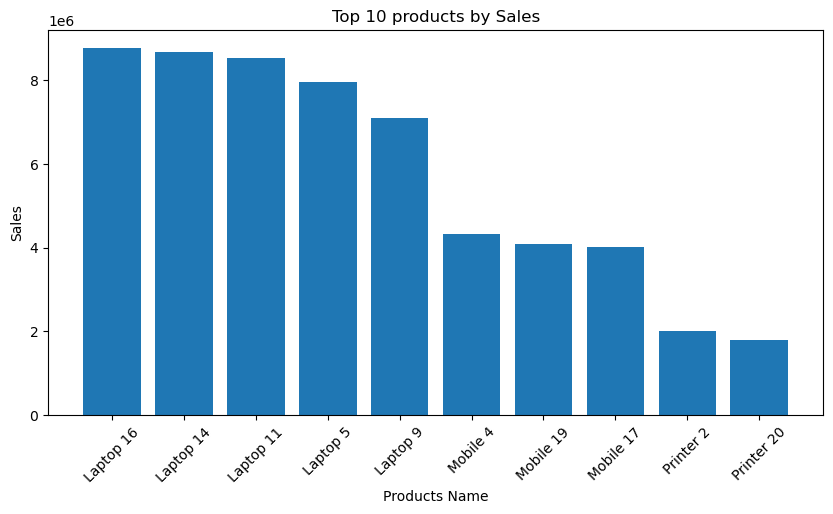

In [64]:
top_products=orders_products.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_products.index,top_products.values)
plt.title("Top 10 products by Sales")
plt.xlabel("Products Name")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

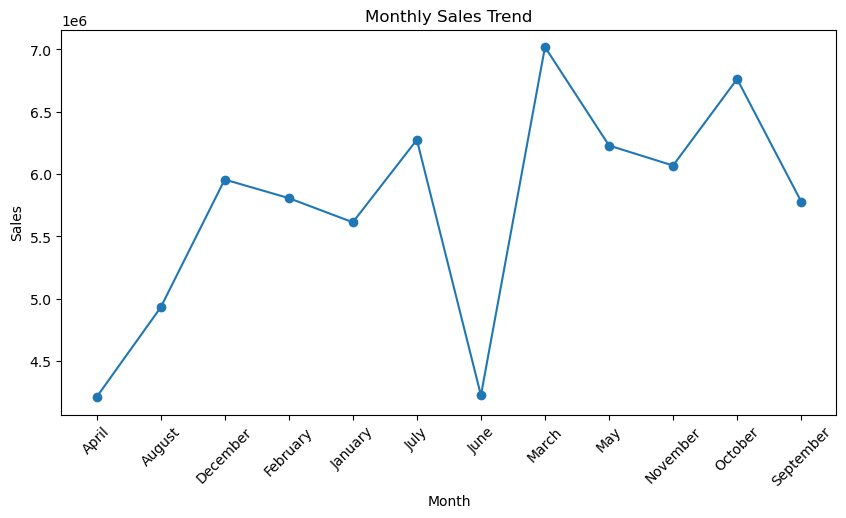

In [88]:
monthly_sales=orders.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

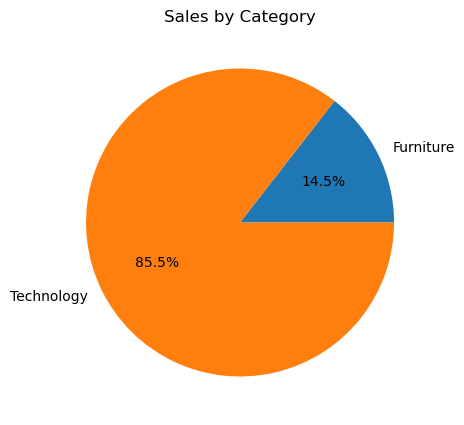

In [71]:
category_sales=orders_products.groupby("Category")["Sales"].sum()

plt.figure(figsize=(10,5))
plt.pie(category_sales.values,labels=category_sales.index,autopct="%1.1f%%")
plt.title("Sales by Category")
plt.show()

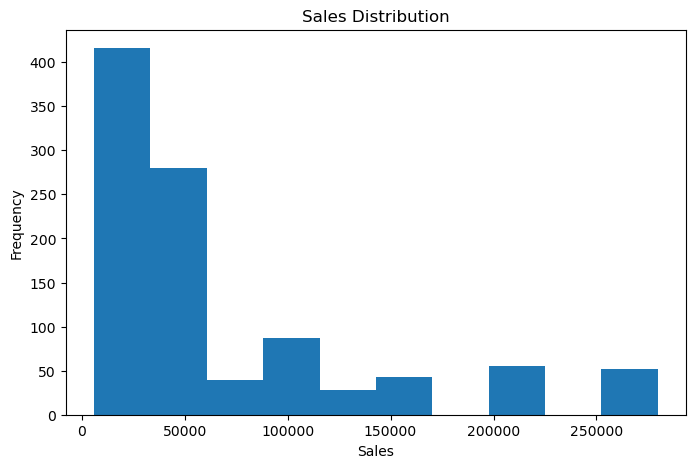

In [75]:
plt.figure(figsize=(8,5))
plt.hist(orders["Sales"],bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

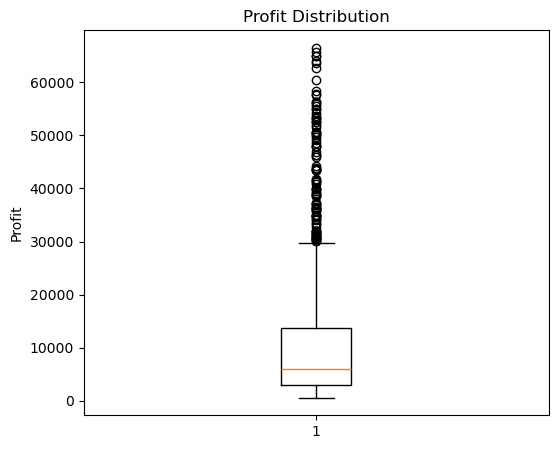

In [78]:
plt.figure(figsize=(6,5))
plt.boxplot(orders["Profit"])
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.show()

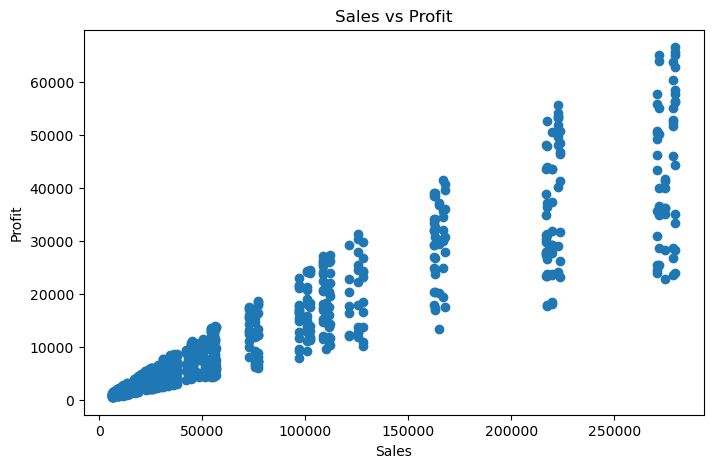

In [79]:
plt.figure(figsize=(8,5))
plt.scatter(orders["Sales"],orders["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

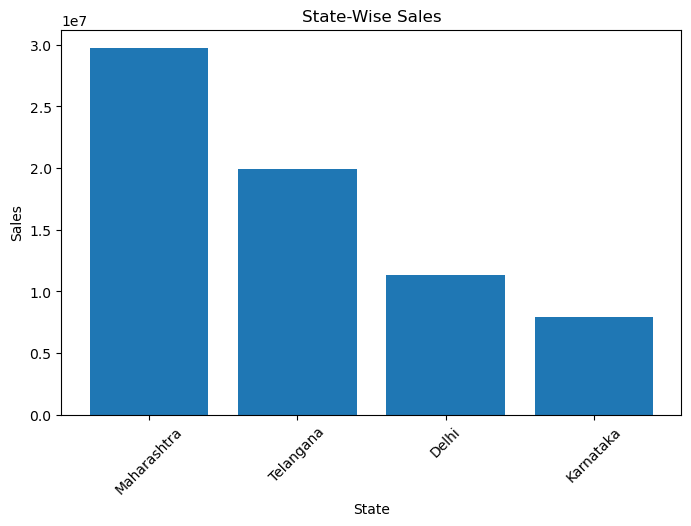

In [82]:
state_sales=orders_customers.groupby("State")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(state_sales.index,state_sales.values)
plt.title("State-Wise Sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

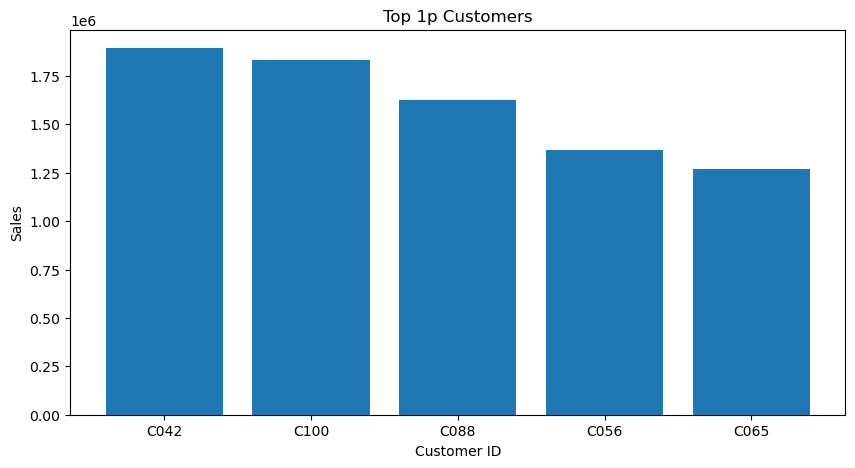

In [86]:
top_customers=orders.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False).head()

plt.figure(figsize=(10,5))
plt.bar(top_customers.index,top_customers.values)
plt.title("Top 1p Customers")
plt.xlabel("Customer ID")
plt.ylabel("Sales")
# plt.xticks(rotation=45)
plt.show()

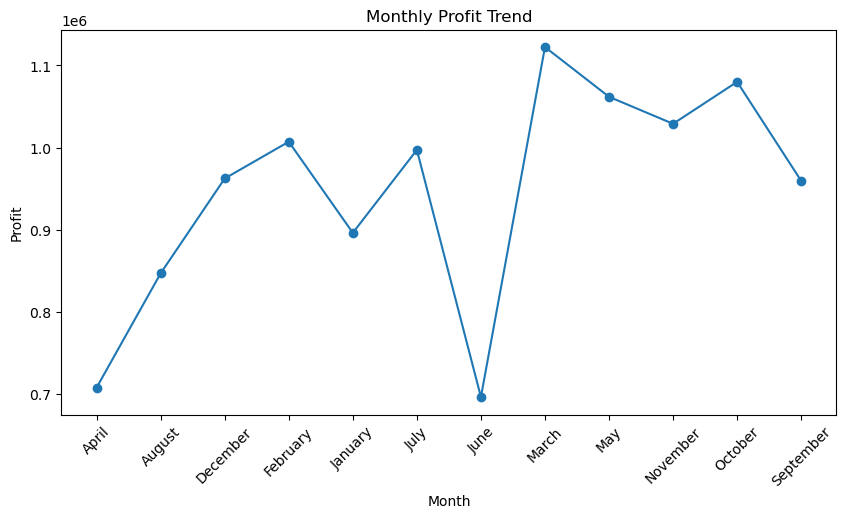

In [89]:
monthly_profit=orders.groupby("Month")["Profit"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_profit.index,monthly_profit.values,marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

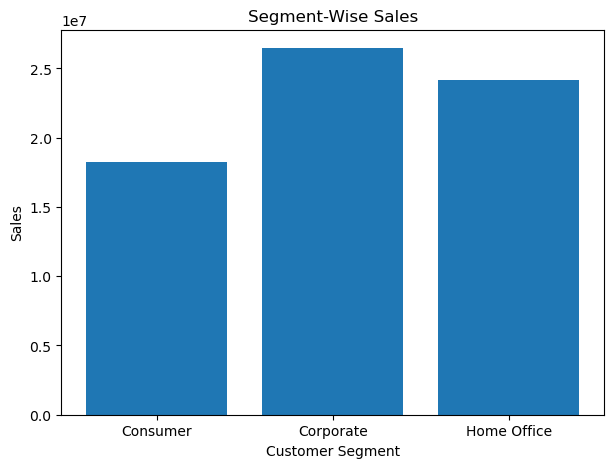

In [96]:
segment_sales=orders_customers.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7,5))
plt.bar(segment_sales.index,segment_sales.values)
plt.title("Segment-Wise Sales")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.show()

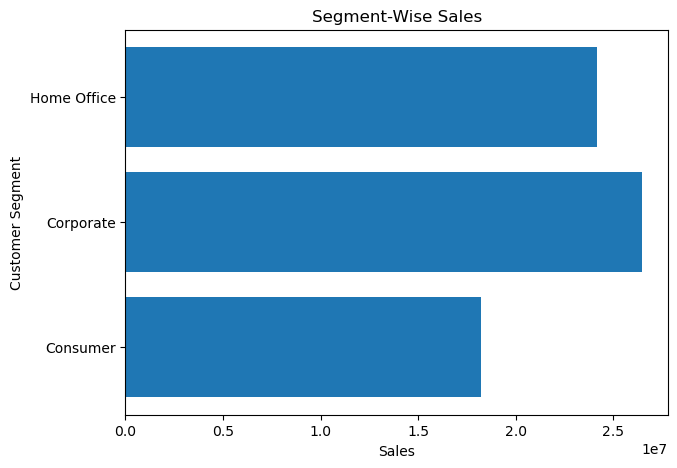

In [98]:
segment_sales=orders_customers.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7,5))
plt.barh(segment_sales.index,segment_sales.values)
plt.title("Segment-Wise Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Segment")
plt.show()